<a href="https://colab.research.google.com/github/prasadw350-lang/Assignments/blob/main/Assignment26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1.(Understanding & Dataset Creation)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs

In [2]:
# Create Dataset

X, y = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=0.70,
    random_state=42
)

In [3]:
# Convert to DataFrame

df = pd.DataFrame(
    X,
    columns=["Feature1", "Feature2"]
)

print(df.shape)

(500, 2)


In [4]:
df.head(10)

,Feature1,Feature2
0,-8.033836,6.831299
1,-8.767448,-6.918116
2,6.172741,1.407361
3,-2.783673,7.989826
4,-6.038777,-7.165762
5,-6.298392,-7.479368
6,-7.046269,7.256281
7,-6.690307,-6.915276
8,3.892545,1.873504
9,-7.317000,-6.861846


Q2. (Data Scaling)

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

X_scaled[:5]

array([[-0.88847363,  0.62990684],
       [-1.02890768, -1.56287499],
       [ 1.83106858, -0.23511276],
       [ 0.11655663,  0.81467072],
       [-0.5065627 , -1.60237008]])

Q3. (Basic K-Means Clustering)



In [6]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

df.head(10)

,Feature1,Feature2,Cluster
0,-8.033836,6.831299,1
1,-8.767448,-6.918116,2
2,6.172741,1.407361,0
3,-2.783673,7.989826,1
4,-6.038777,-7.165762,2
5,-6.298392,-7.479368,2
6,-7.046269,7.256281,1
7,-6.690307,-6.915276,2
8,3.892545,1.873504,0
9,-7.317000,-6.861846,2


Q4. (Visualizing Clusters)

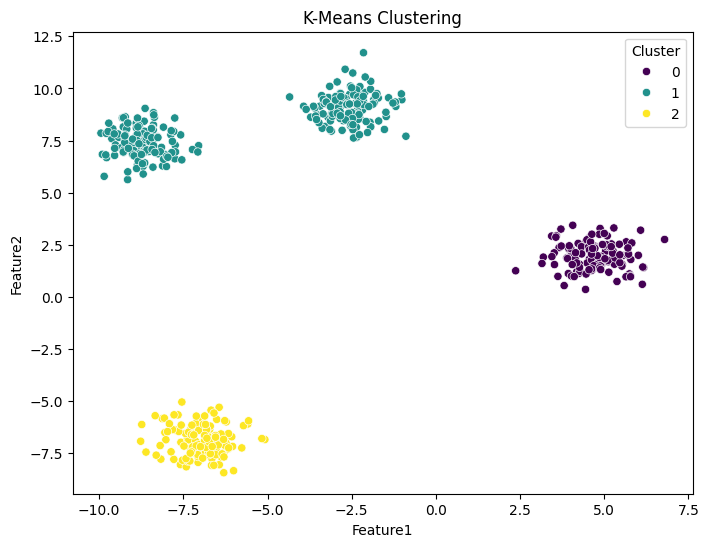

In [7]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Feature1",
    y="Feature2",
    hue="Cluster",
    palette="viridis"
)

plt.title("K-Means Clustering")
plt.xlabel("Feature1")
plt.ylabel("Feature2")

plt.show()

Q5. (Elbow Method – Finding Optimal K)

In [8]:
wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

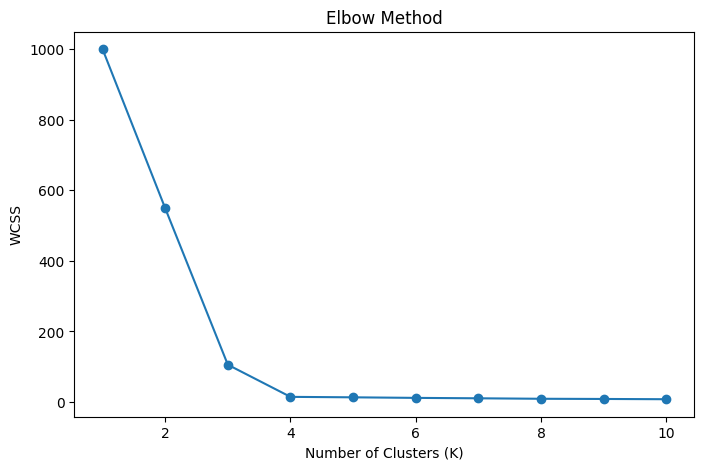

In [9]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.show()

Q6. (Final K-Means Model)6

In [10]:
final_model = KMeans(
    n_clusters=4,
    random_state=42
)

df["Final_Cluster"] = final_model.fit_predict(X_scaled)

df.head()

,Feature1,Feature2,Cluster,Final_Cluster
0,-8.033836,6.831299,1,1
1,-8.767448,-6.918116,2,2
2,6.172741,1.407361,0,0
3,-2.783673,7.989826,1,3
4,-6.038777,-7.165762,2,2


In [11]:
print(df["Final_Cluster"].value_counts())

Final_Cluster
1    125
2    125
0    125
3    125
Name: count, dtype: int64


Q7. (Visualizing Final Clusters)

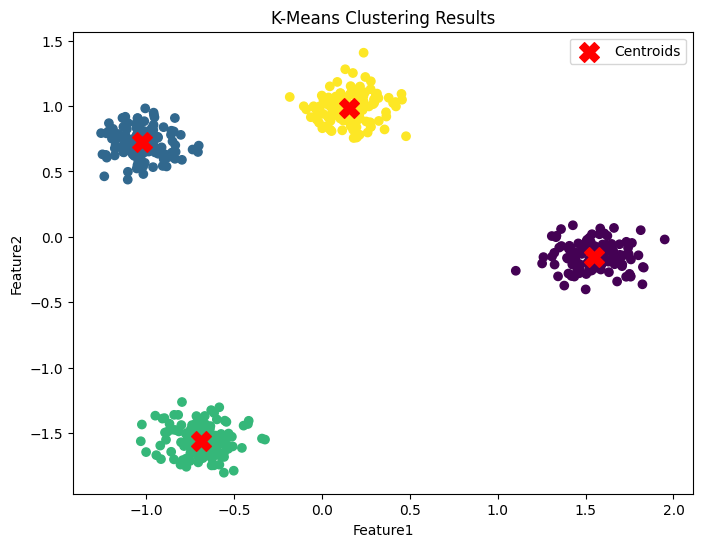

In [12]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=df["Final_Cluster"],
    cmap="viridis"
)
plt.scatter(
    final_model.cluster_centers_[:,0],
    final_model.cluster_centers_[:,1],
    color="red",
    marker="X",
    s=200,
    label="Centroids"
)
plt.title("K-Means Clustering Results")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.legend()

plt.show()

Q8. (Real Dataset Application)

In [13]:
from sklearn.datasets import load_iris

iris = load_iris()

df_iris = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [14]:
X = df_iris

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [16]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df_iris["Cluster"] = kmeans.fit_predict(X_scaled)

In [17]:
print(df_iris["Cluster"].value_counts())

Cluster
0    96
1    33
2    21
Name: count, dtype: int64


Q9. (Elbow Method on Real Dataset)

In [18]:
wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

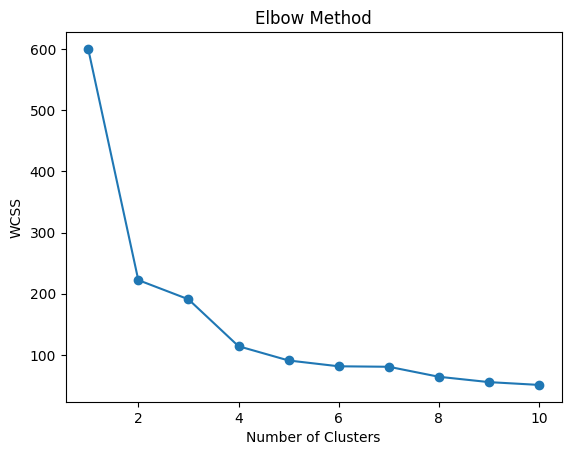

In [19]:
import matplotlib.pyplot as plt

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [20]:
final_model = KMeans(
    n_clusters=3,
    random_state=42
)

df_iris["Final_Cluster"] = final_model.fit_predict(X_scaled)

In [21]:
print(df_iris["Final_Cluster"].value_counts())

Final_Cluster
0    96
1    33
2    21
Name: count, dtype: int64


Q10. (Mini Project – Complete Clustering Pipeline)

In [22]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [23]:
from sklearn.preprocessing import StandardScaler

X = df

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

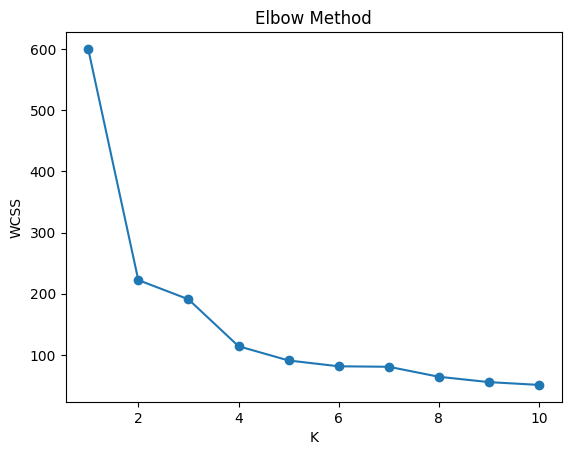

In [24]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

plt.plot(range(1,11), wcss, marker="o")

plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [25]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

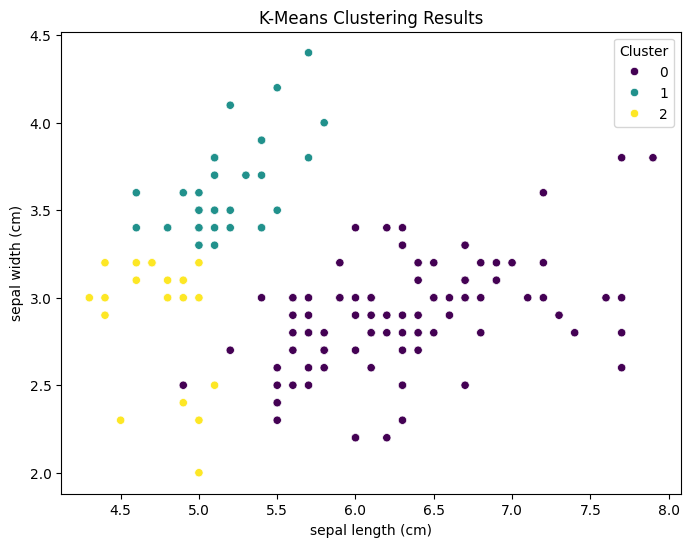

In [26]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="sepal length (cm)",
    y="sepal width (cm)",
    hue="Cluster",
    palette="viridis"
)

plt.title("K-Means Clustering Results")

plt.show()

In [28]:
print(df["Cluster"].value_counts())

Cluster
0    96
1    33
2    21
Name: count, dtype: int64
